<a href="https://colab.research.google.com/github/AkankshaB123/Optimisation/blob/main/Classification_Hyperparam(Session22_2ndPart).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classification

In [117]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

In [118]:
import pandas as pd
df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [71]:
# X = df.drop(columns = ['target'], inplace = True)
# y = df['target']

In [119]:
X = cancer['data'] # input features
y = cancer['target'] #target variable

In [120]:
print(cancer.target_names) # binary Classification problem

['malignant' 'benign']


In [121]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [122]:
y = cancer.target
X = cancer.data

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)

1D -> (samples)

2D -> (samples, features)

In [124]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 30)
y_train shape: (455,)
X_test shape: (114, 30)


In [125]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [126]:
accuracy_score(y_test, y_pred)*100

95.6140350877193

# Random Forest Classifier

In [127]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [128]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
y = cancer.target
X = cancer.data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
model = RandomForestClassifier(n_estimators=50, criterion = 'entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [129]:
accuracy_score(y_test, y_pred)*100

96.49122807017544

In [130]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
y = cancer.target
X = cancer.data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
model = DecisionTreeClassifier(criterion = 'entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [131]:
accuracy_score(y_test, y_pred)*100

94.73684210526315

### **Hyperparameters; process: hyperparameter tuning**

Upon changing hyperparameters(eg. n_estimators, criterion), the performance of the model changes)

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
y = cancer.target
X = cancer.data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
model = RandomForestClassifier(n_estimators= 2, criterion = 'entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [133]:
accuracy_score(y_test, y_pred)*100

89.47368421052632

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
y = cancer.target
X = cancer.data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
model = RandomForestClassifier(n_estimators= 5, criterion = 'gini')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [141]:
accuracy_score(y_test, y_pred)*100

97.36842105263158

#### Two dimensions of Optimisation

1. Which model to use? - Try out all models, enhance best model, tune their hyperparameters
a. RFC b. DTC c. XGBoost (97.3, 96.5, 98.5)

2. **For the top models, what hyper-parameters to choose so they perform better than their default setting?** (Causal hyper-parameters)

3. Hyperparameters Tuning: Random Search, Grid Search, Ray Site

In [142]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[41,  2],
       [ 1, 70]])

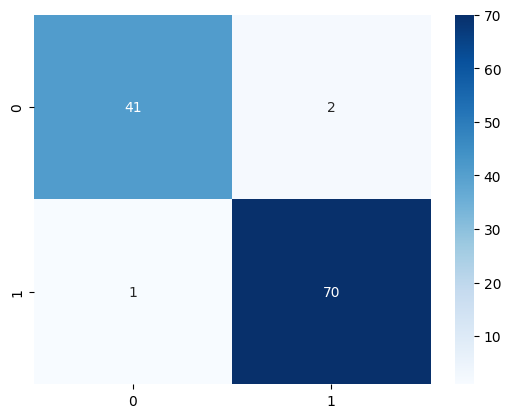

In [143]:
# heatmap
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,cmap= 'Blues', fmt = 'd')
plt.show()

ROC - AUC (pending)